In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser("~/projects/language-table"))

import nest_asyncio; nest_asyncio.apply()
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from language_table.environments.language_table import LanguageTable
from language_table.environments.blocks import LanguageTableBlockVariants
from language_table.environments.rewards.block2block import BlockToBlockReward
from language_table.lamer.lava_policy import LAVAPolicy
from language_table.lamer.state_to_text import state_to_text


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-22 14:52:49.438614: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 14:52:49.458834: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-22 14:52:49.514115: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-22 14:52:49.515392: I tensorflow/core/platform/cpu_feature_guar

In [2]:
env = LanguageTable(
    block_mode=LanguageTableBlockVariants("BLOCK_4"),
    reward_factory=BlockToBlockReward,
    seed=42,
)

policy = LAVAPolicy(
    checkpoint_dir="/gpfs/scrubbed/memmelma/.cache/checkpoints/language_table",
    checkpoint_prefix="bc_resnet_sim_checkpoint_955000",
    action_clip=0.1,
)
print("Env and policy ready.")

argv[0]=


/gpfs/projects/weirdlab/memmelma/.cache/conda/envs/langtable/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Env and policy ready.


2026-03-22 14:52:58.225337: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
def run_command(command: str, max_steps: int = 200):
    policy.reset(num_envs=1)
    
    obs = env._compute_observation()
    frames = [env.render(mode="rgb_array")]
    total_reward = 0.0
    info = {}

    state_text = state_to_text(env._last_state)
    print(f"Current state:\n{state_text}\n")
    print(f"Command: {command}\n")

    for i in range(max_steps):
        actions = policy.predict(
            goals=[command],
            obs_list=[obs],
            active_mask=np.array([True]),
        )
        action = actions[0]

        obs, reward, done, info = env.step(action)
        frames.append(env.render(mode="rgb_array"))
        total_reward += reward
        if done:
            print(f"  Done at step {i+1}!")
            break

    print(f"\nTotal reward: {total_reward:.3f}  |  Won: {info.get('won', False)}")
    print(f"Final state:\n{state_to_text(env._last_state)}")
    return frames, total_reward, info

def show_rollout(frames, fps=5):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis("off")
    img = ax.imshow(frames[0])
    ax.set_title(f"Rollout  ({len(frames)} frames)")

    def update(i):
        img.set_data(frames[i])
        return [img]

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames),
        interval=1000 / fps, blit=True
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())


Task: push the moon towards the cube
End-effector: (0.314, 0.051)
Blocks: blue_cube (0.406, -0.148), green_star (0.510, 0.139), red_moon (0.315, -0.060), yellow_pentagon (0.428, -0.027)


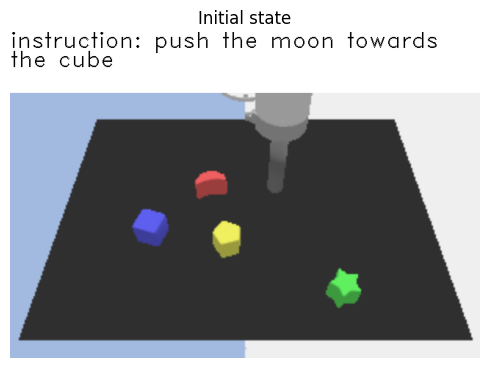

In [4]:
env.reset()
state = env._last_state

print(state_to_text(state))

plt.figure(figsize=(5, 5))
plt.imshow(env.render(mode="rgb_array"))
plt.axis("off")
plt.title("Initial state")
plt.tight_layout()
plt.show()

In [7]:
env.reset()

# frames, reward, info = await run_command("move to the red moon")
# frames, reward, info = await run_command("move behind the green star, then push it to the blue cube")
# frames, reward, info = await run_command(f"move to (0,0)")
frames, reward, info = run_command(f"push the red moon in the left corner")

show_rollout(frames)

Current state:
Task: push the blue cube close to the pentagon
End-effector: (0.352, -0.046)
Blocks: blue_cube (0.406, 0.192), green_star (0.477, -0.023), red_moon (0.234, -0.135), yellow_pentagon (0.424, 0.075)

Command: push the red moon in the left corner



2026-03-22 14:55:23.121663: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


RuntimeError: Unable to initialize backend 'cuda': FAILED_PRECONDITION: No visible GPU devices. (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)